In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

warnings.filterwarnings("ignore")

# Memuat data (Sesuaikan path file dengan drive Anda)
historical = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/Wind Power/wind farm historical data.csv")
nwp = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/Wind Power/NWP.csv")

# Pembersihan kolom dan format waktu
historical.columns = historical.columns.str.strip()
nwp.columns = nwp.columns.str.strip()
historical['Date'] = pd.to_datetime(historical['Date'], dayfirst=True)
nwp['time'] = pd.to_datetime(nwp['time'])

# Penamaan ulang kolom agar konsisten dengan fitur fisik
historical = historical.rename(columns={'Date':'timestamp', 'Speed':'wind_speed', 'Energy':'power'})
nwp = nwp.rename(columns={'time':'timestamp', 'mod':'wind_speed_nwp', 'temp':'temperature_nwp',
                          'rh':'humidity_nwp', 'mslp':'pressure_nwp'})

# Penggabungan data
data = pd.merge(historical, nwp, on='timestamp', how='inner').sort_values('timestamp').reset_index(drop=True)
data = data.ffill().dropna()

In [2]:
data_fe = data.copy()

# Fitur Waktu (Siklus Harian)
data_fe['hour'] = data_fe['timestamp'].dt.hour
data_fe['month'] = data_fe['timestamp'].dt.month
data_fe['hour_sin'] = np.sin(2*np.pi*data_fe['hour']/24)
data_fe['hour_cos'] = np.cos(2*np.pi*data_fe['hour']/24)

# Fitur Lag (Ketergantungan waktu jangka pendek) [cite: 76, 78]
for lag in [1, 2, 3, 6, 12, 24]:
    data_fe[f'power_lag_{lag}'] = data_fe['power'].shift(lag)

# Fitur Berbasis Fisika (Dynamic Pressure Model)
# Konversi suhu ke Kelvin dan tekanan ke Pascal [cite: 140, 154]
data_fe['temp_kelvin'] = data_fe['temperature_nwp'] + 273.15
data_fe['pressure_pascal'] = data_fe['pressure_nwp'] * 100
R_specific = 287.058 # Konstanta gas ideal [cite: 158]

# Menghitung Kerapatan Udara (Air Density) [cite: 154]
data_fe['air_density'] = data_fe['pressure_pascal'] / (R_specific * data_fe['temp_kelvin'])

# Menghitung Theoretical Wind Power (P proporsional terhadap v^3) [cite: 169, 177]
data_fe['physics_theoretical_power'] = 0.5 * data_fe['air_density'] * (data_fe['wind_speed_nwp']**3)

data_fe = data_fe.dropna().reset_index(drop=True)

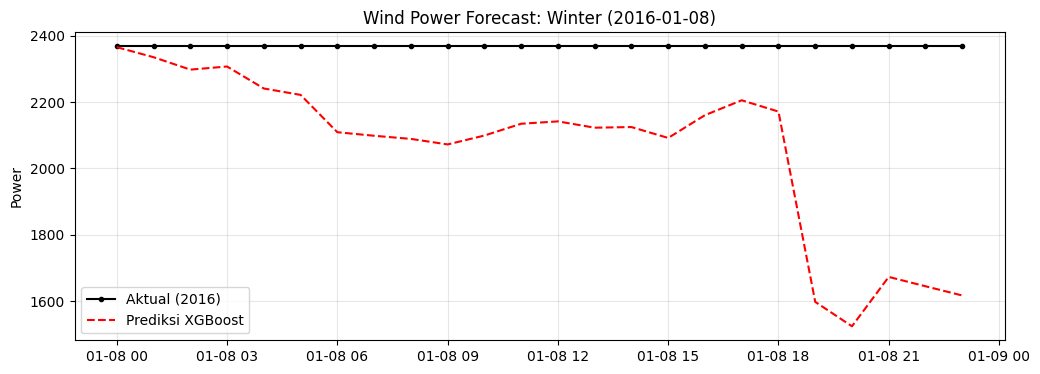

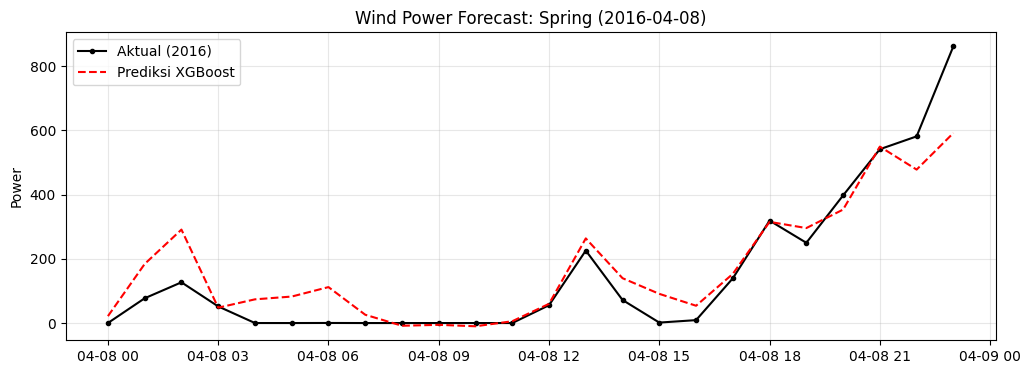

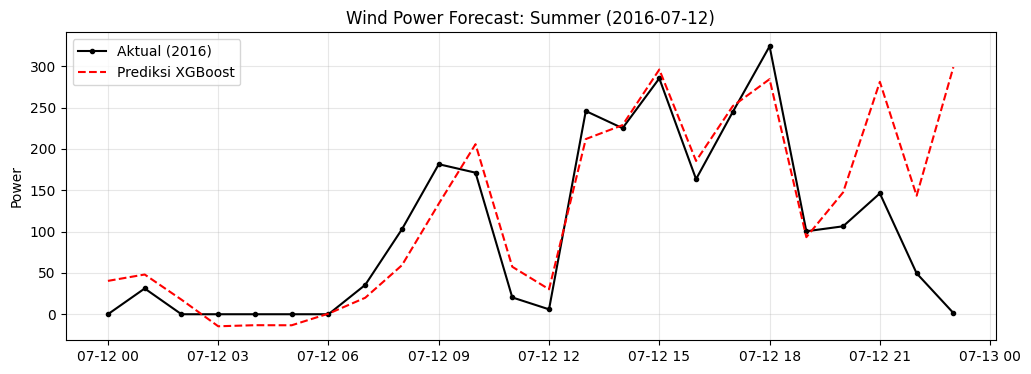

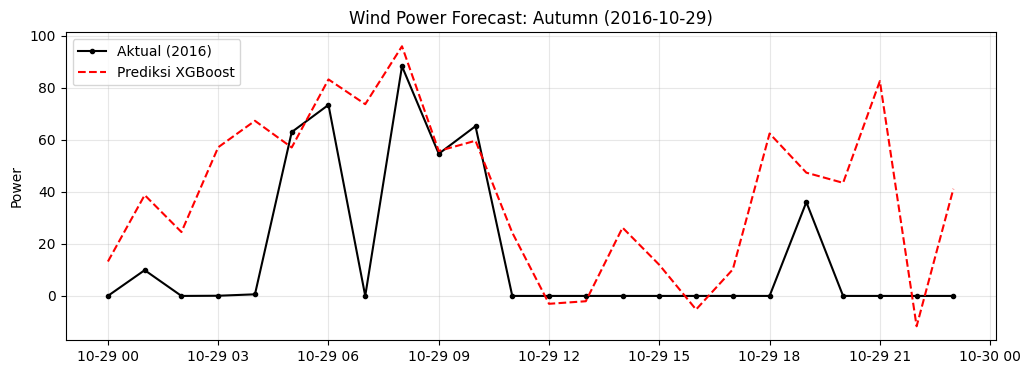

   Season        Date        RMSE         MAE        R2
0  Winter  2016-01-08  392.700448  307.477455  0.000000
1  Spring  2016-04-08   83.814685   56.417515  0.862539
2  Summer  2016-07-12   73.886917   42.133186  0.489693
3  Autumn  2016-10-29   36.014592   26.252181 -0.601786


In [3]:
# =====================================================
# 3. PERBAIKAN: PENGUJIAN 4 MUSIM (TAHUN 2016)
# =====================================================

# Menyesuaikan tahun ke 2016 sesuai dataset Anda
seasonal_test_dates = {
    'Winter': '2016-01-08',
    'Spring': '2016-04-08',
    'Summer': '2016-07-12',
    'Autumn': '2016-10-29'
}

results_final = []
features = data_fe.drop(['timestamp', 'power', 'month'], axis=1, errors='ignore').columns

# Hyperparameter yang sudah di-tuning (Best Params dari percobaan sebelumnya)
best_params = {
    'n_estimators': 1000,
    'max_depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

for season, date_str in seasonal_test_dates.items():
    test_date = pd.to_datetime(date_str).date()

    # Train: Data sebelum tanggal uji
    train_data = data_fe[data_fe['timestamp'].dt.date < test_date]
    # Test: Tepat pada tanggal tersebut
    test_data = data_fe[data_fe['timestamp'].dt.date == test_date]

    # Proteksi jika data pada tanggal tersebut tidak ada di dataset 2016 Anda
    if len(train_data) == 0 or len(test_data) == 0:
        print(f"Data untuk tanggal {date_str} ({season}) tidak ditemukan, melewati...")
        continue

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(train_data[features])
    X_test = scaler.transform(test_data[features])
    y_train = train_data['power']
    y_test = test_data['power']

    model = XGBRegressor(**best_params, objective='reg:squarederror', random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results_final.append({
        'Season': season,
        'Date': date_str,
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds),
        'R2': r2_score(y_test, preds)
    })

    # Visualisasi Line Chart per musim
    plt.figure(figsize=(12, 4))
    plt.plot(test_data['timestamp'], y_test, label='Aktual (2016)', color='black', marker='o', markersize=3)
    plt.plot(test_data['timestamp'], preds, label='Prediksi XGBoost', color='red', linestyle='--')
    plt.title(f'Wind Power Forecast: {season} ({date_str})')
    plt.ylabel('Power')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

final_seasonal_df = pd.DataFrame(results_final)
print(final_seasonal_df)